In [8]:
import pandas as pd
import coiled
import yaml
import geodatasets
import geopandas as gpd
import math
import rasterio
import os
import openpyxl
import pygwalker as pyg
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.lines as mlines
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import re
import sys
import textwrap
from shapely.geometry import Point
from datetime import datetime
from pathlib import Path
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator
from matplotlib.transforms import blended_transform_factory
from matplotlib.gridspec import GridSpec
from matplotlib.collections import LineCollection
from io import BytesIO
from IPython.display import Image, display as ipy_display
from rasterio.windows import Window
from tqdm.notebook import tqdm
from dask.distributed import Client, as_completed

In [15]:
# To add project files
# Keeps going up project structure until it gets to the root.
# Per https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c-afolu-flux-model/c/69a5ff07-91e0-8329-88d1-cf2ea6c159c2
project_root = Path().resolve()
while project_root.name != "AFOLU_GHG_flux_model":
    project_root = project_root.parent

sys.path.append(str(project_root))

from src.utilities import constants_and_names as cn
from src.utilities import universal_utilities as uu
from src.utilities.create_cluster import create_cluster as cc_create_cluster

now = datetime.now()
today = now.strftime("%Y%m%d")

pd.set_option('display.max_columns', None)

Chunks to process: 4


Processing chunks (2024):   0%|          | 0/4 [00:00<?, ?it/s]

Done — processed: 4  |  missing/skipped: 0


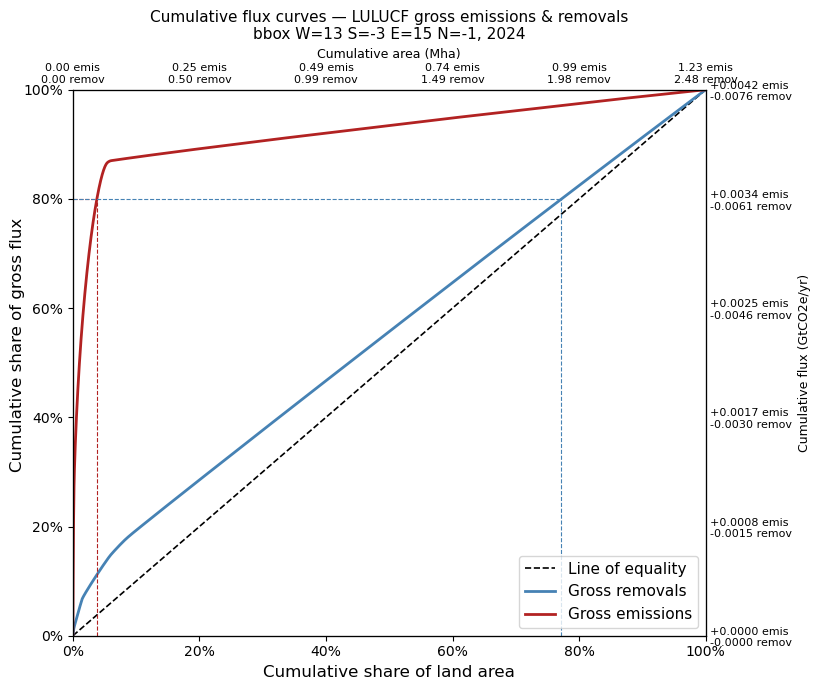

VALIDATION SUMMARY

Year             : 2024
Chunks processed : 4  |  missing: 0
Histogram bins   : 10,000  (log 1e-06–1e+05 MgCO2e/ha/yr)

Land area covered:
  Emitting land         :       1.23 Mha
  Removing land         :       2.48 Mha

Total fluxes  ← compare against known model output:
  Gross emissions       : +   0.00421 GtCO2e/yr
  Gross removals        : -   0.00760 GtCO2e/yr
  Net (emis − remv)     :    -0.00338 GtCO2e/yr

Concentration — emissions (total: 1.23 Mha, +0.00421 GtCO2e/yr):
  Top 10% most intensive (0.12 Mha) → 88.0% of gross emissions (+0.00371 GtCO2e/yr)
  Top 25% most intensive (0.31 Mha) → 91.2% of gross emissions (+0.00384 GtCO2e/yr)
  Top 50% most intensive (0.62 Mha) → 95.0% of gross emissions (+0.00400 GtCO2e/yr)

Concentration — removals (total: 2.48 Mha, -0.00760 GtCO2e/yr):
  Top 10% most intensive (0.25 Mha) → 19.4% of gross removals (-0.00147 GtCO2e/yr)
  Top 25% most intensive (0.62 Mha) → 35.7% of gross removals (-0.00271 GtCO2e/yr)
  Top 50% most

In [25]:
%%time

### Global (or regional) cumulative flux curves from 1x1 deg per-ha tiles
### Histogram approach: memory-efficient, scalable to global
### Reuses project chunk list utilities from universal_utilities.py
### Per Claude session `Lorenz curves for LULUCF emissions/removals` and 'Lorenz curves for LULUCF emissions/removals, pt2' 


# ── Configuration ──────────────────────────────────────────────────────────
YEAR = 2024

SINGLE_CHUNK  = None
BOUNDING_BOX  = [13, -3, 15, -1]
SHAPEFILE_URI = None
FIRST_CHUNKS  = None

N_BINS        = 10_000
INTENSITY_MIN = 1e-6    # MgCO2e/ha/yr
INTENSITY_MAX = 1e5     # MgCO2e/ha/yr

MIN_VALID_PIXELS = 1_000
N_PLOT_POINTS    = 500

BASE     = ("s3://gfw2-data/climate/AFOLU_flux_model/LULUCF/outputs_vegetation/"
            "version_1_0_5__standard__global")
EMIS_DIR = (f"{BASE}/gross_emissions__all_C_pools__all_gases__MgCO2e/"
            f"annual_intervals/{YEAR}/_ha_yr/4000_pixels/20260130")
REMV_DIR = (f"{BASE}/gross_removals__all_C_pools__MgCO2/"
            f"annual_intervals/{YEAR}/_ha_yr/4000_pixels/20260130")

# ── Build chunk list ───────────────────────────────────────────────────────
if SINGLE_CHUNK is not None:
    chunk_list = [SINGLE_CHUNK]
    area_label = f"chunk {SINGLE_CHUNK}"
elif BOUNDING_BOX is not None:
    chunk_list = uu.get_chunk_bounds_from_bounding_box(BOUNDING_BOX, chunk_size=1.0)
    area_label = f"bbox W={BOUNDING_BOX[0]} S={BOUNDING_BOX[1]} E={BOUNDING_BOX[2]} N={BOUNDING_BOX[3]}"
elif SHAPEFILE_URI is not None:
    fishnet_iso_df = uu.fishnet_with_GADM_iso(SHAPEFILE_URI)
    if FIRST_CHUNKS:
        fishnet_iso_df = fishnet_iso_df[:FIRST_CHUNKS]
    chunk_list = fishnet_iso_df['chunk_id'].apply(uu.process_chunk_id).tolist()
    area_label = SHAPEFILE_URI.split('/')[-1]
else:
    raise ValueError("Set one of SINGLE_CHUNK, BOUNDING_BOX, or SHAPEFILE_URI")

print(f"Chunks to process: {len(chunk_list):,}")

# ── S3 path builder ────────────────────────────────────────────────────────
def chunk_s3_paths(bounds, year, emis_dir, remv_dir):
    w, s, e, n = bounds
    tile_id    = uu.xy_to_tile_id(w, n)
    bounds_str = uu.boundstr(bounds)
    emis = (f"{emis_dir}/{tile_id}__{bounds_str}__"
            f"gross_emissions__all_C_pools__all_gases__MgCO2e_ha_yr_{year}.tif")
    remv = (f"{remv_dir}/{tile_id}__{bounds_str}__"
            f"gross_removals__all_C_pools__MgCO2_ha_yr_{year}.tif")
    return emis, remv

# ── Pixel area (ha) by row for a WGS84 raster ─────────────────────────────
def pixel_area_ha_by_row(src):
    t           = src.transform
    row_idx     = np.arange(src.height)
    lat_centers = t.f + (row_idx + 0.5) * t.e
    d_lat_rad   = abs(t.e) * np.pi / 180
    d_lon_rad   = abs(t.a) * np.pi / 180
    area_km2    = 6371.0**2 * d_lat_rad * d_lon_rad * np.cos(np.deg2rad(lat_centers))
    return area_km2 * 100   # km² → ha

# ── Histogram bins (log scale) ─────────────────────────────────────────────
bin_edges = np.logspace(np.log10(INTENSITY_MIN), np.log10(INTENSITY_MAX), N_BINS + 1)

emis_bin_area = np.zeros(N_BINS, dtype=np.float64)
emis_bin_flux = np.zeros(N_BINS, dtype=np.float64)
remv_bin_area = np.zeros(N_BINS, dtype=np.float64)
remv_bin_flux = np.zeros(N_BINS, dtype=np.float64)

n_ok      = 0
n_missing = 0

# ── Main loop: accumulate histogram over all chunks ───────────────────────
for bounds in tqdm(chunk_list, desc=f"Processing chunks ({YEAR})"):
    emis_path, remv_path = chunk_s3_paths(bounds, YEAR, EMIS_DIR, REMV_DIR)

    try:
        with rasterio.open(emis_path) as src:
            emis_grid = src.read(1).astype(np.float64)
            areas_1d  = pixel_area_ha_by_row(src)
            area_grid = np.broadcast_to(areas_1d[:, np.newaxis], emis_grid.shape)
        with rasterio.open(remv_path) as src:
            remv_grid = src.read(1).astype(np.float64)
    except Exception:
        n_missing += 1
        continue

    emis_mask = emis_grid > 0
    if emis_mask.any():
        e_ha      = emis_grid[emis_mask]
        e_ha_area = area_grid[emis_mask]
        e_flux    = e_ha * e_ha_area
        bidx      = np.clip(
            np.searchsorted(bin_edges, e_ha, side='right') - 1, 0, N_BINS - 1
        )
        emis_bin_area += np.bincount(bidx, weights=e_ha_area, minlength=N_BINS)
        emis_bin_flux += np.bincount(bidx, weights=e_flux,    minlength=N_BINS)

    remv_mask = remv_grid < 0
    if remv_mask.any():
        r_ha      = np.abs(remv_grid[remv_mask])
        r_ha_area = area_grid[remv_mask]
        r_flux    = r_ha * r_ha_area
        bidx      = np.clip(
            np.searchsorted(bin_edges, r_ha, side='right') - 1, 0, N_BINS - 1
        )
        remv_bin_area += np.bincount(bidx, weights=r_ha_area, minlength=N_BINS)
        remv_bin_flux += np.bincount(bidx, weights=r_flux,    minlength=N_BINS)

    n_ok += 1

print(f"Done — processed: {n_ok:,}  |  missing/skipped: {n_missing:,}")

# ── Reconstruct Lorenz curve from histogram (descending intensity) ─────────
def lorenz_from_histogram(bin_area, bin_flux):
    """Sort descending by intensity (highest first) → curve goes up-then-right,
    above the diagonal. Returns (cum_area_frac, cum_flux_frac), both 0→1."""
    occupied  = (bin_area > 0) | (bin_flux > 0)
    # Reverse: highest-intensity bins first
    cum_area  = np.concatenate([[0.0], np.cumsum(bin_area[occupied][::-1])])
    cum_flux  = np.concatenate([[0.0], np.cumsum(bin_flux[occupied][::-1])])
    return cum_area / cum_area[-1], cum_flux / cum_flux[-1]

def gini(x, y):
    """For a curve above the diagonal (descending sort): Gini = 2*trapz(y,x) - 1."""
    return 2.0 * np.trapezoid(y, x) - 1.0

emis_x, emis_y = lorenz_from_histogram(emis_bin_area, emis_bin_flux)
remv_x,  remv_y = lorenz_from_histogram(remv_bin_area,  remv_bin_flux)

emis_area_Mha = emis_bin_area.sum() / 1e6
remv_area_Mha = remv_bin_area.sum() / 1e6
emis_flux_Gt  = emis_bin_flux.sum() / 1e9
remv_flux_Gt  = remv_bin_flux.sum() / 1e9

# ── Plot ───────────────────────────────────────────────────────────────────
# x = cumulative area fraction (descending intensity → high-intensity land first)
# y = cumulative flux fraction
# Curves bulge above the diagonal → "up, then right"
pct_ticks = np.array([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])

fig, ax = plt.subplots(figsize=(8, 7))

ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Line of equality')
ax.plot(remv_x, remv_y, color='steelblue', lw=2,
        label=f'Gross removals') #   (Gini = {gini(remv_x, remv_y):.3f})')
ax.plot(emis_x, emis_y, color='firebrick', lw=2,
        label=f'Gross emissions') #  (Gini = {gini(emis_x, emis_y):.3f})')

# 80% emissions reference lines
x_80  = np.interp(0.80, emis_y, emis_x)
y_80  = 0.80

ax.axvline(x=x_80,  ymin=0, ymax=y_80,  color='firebrick', lw=0.8, ls='--')
ax.axhline(y=y_80,  xmin=0, xmax=x_80,  color='firebrick', lw=0.8, ls='--')

# 80% removals reference lines
x_80r = np.interp(0.80, remv_y, remv_x)
y_80r = 0.80

ax.axvline(x=x_80r, ymin=0, ymax=y_80r, color='steelblue', lw=0.8, ls='--')
ax.axhline(y=y_80r, xmin=0, xmax=x_80r, color='steelblue', lw=0.8, ls='--')


ax.set_xlabel('Cumulative share of land area', fontsize=12)
# ax.set_ylabel('Cumulative share of gross flux', fontsize=12)
ax.set_title(
    f'Cumulative flux curves — LULUCF gross emissions & removals\n{area_label}, {YEAR}',
    fontsize=11
)
ax.legend(fontsize=11, loc='lower right')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_box_aspect(1)

# ── Secondary axes ─────────────────────────────────────────────────────────
ax_right = ax.twinx()
ax_top   = ax.twiny()

ax.set_xticks(pct_ticks)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_yticks(pct_ticks)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

# Right y-axis: cumulative flux (GtCO2e/yr) — matches y-axis
ax_right.set_ylim(0, 1)
ax_right.set_yticks(pct_ticks)
ax_right.set_yticklabels(
    [f"+{v * emis_flux_Gt:.4f} emis\n{-v * remv_flux_Gt:.4f} remov" for v in pct_ticks],
    fontsize=8
)
ax_right.set_ylabel('Cumulative flux (GtCO2e/yr)', fontsize=9)
ax_right.tick_params(axis='y', length=0)

# Top x-axis: cumulative area (Mha) — matches x-axis
ax_top.set_xlim(0, 1)
ax_top.set_xticks(pct_ticks)
ax_top.set_xticklabels(
    [f"{v * emis_area_Mha:.2f} emis\n{v * remv_area_Mha:.2f} remov" for v in pct_ticks],
    fontsize=8
)
ax_top.set_xlabel('Cumulative area (Mha)', fontsize=9)
ax_top.tick_params(axis='x', length=0)

# Primary y-axis title
fig.text(-0.02, 0.5, 'Cumulative share of gross flux',
         fontsize=12, va='center', rotation='vertical')

plt.tight_layout()
plt.show()

# ── Validation summary ─────────────────────────────────────────────────────
print("=" * 57)
print("VALIDATION SUMMARY")
print("=" * 57)
print(f"\nYear             : {YEAR}")
print(f"Chunks processed : {n_ok:,}  |  missing: {n_missing:,}")
print(f"Histogram bins   : {N_BINS:,}  (log {INTENSITY_MIN:.0e}–{INTENSITY_MAX:.0e} MgCO2e/ha/yr)")

print(f"\nLand area covered:")
print(f"  Emitting land         : {emis_area_Mha:>10.2f} Mha")
print(f"  Removing land         : {remv_area_Mha:>10.2f} Mha")

print(f"\nTotal fluxes  ← compare against known model output:")
print(f"  Gross emissions       : +{emis_flux_Gt:>10.5f} GtCO2e/yr")
print(f"  Gross removals        : -{remv_flux_Gt:>10.5f} GtCO2e/yr")
print(f"  Net (emis − remv)     : {emis_flux_Gt - remv_flux_Gt:>+11.5f} GtCO2e/yr")

print(f"\nConcentration — emissions (total: {emis_area_Mha:.2f} Mha, +{emis_flux_Gt:.5f} GtCO2e/yr):")
for pct in [10, 25, 50]:
    idx       = np.searchsorted(emis_x, pct / 100)
    flux_frac = emis_y[idx]
    print(f"  Top {pct:2d}% most intensive ({pct/100 * emis_area_Mha:.2f} Mha) → "
          f"{100*flux_frac:.1f}% of gross emissions (+{flux_frac * emis_flux_Gt:.5f} GtCO2e/yr)")

print(f"\nConcentration — removals (total: {remv_area_Mha:.2f} Mha, -{remv_flux_Gt:.5f} GtCO2e/yr):")
for pct in [10, 25, 50]:
    idx       = np.searchsorted(remv_x, pct / 100)
    flux_frac = remv_y[idx]
    print(f"  Top {pct:2d}% most intensive ({pct/100 * remv_area_Mha:.2f} Mha) → "
          f"{100*flux_frac:.1f}% of gross removals (-{flux_frac * remv_flux_Gt:.5f} GtCO2e/yr)")

print(f"\nGini coefficients:")
print(f"  Gross emissions       : {gini(emis_x, emis_y):.4f}")
print(f"  Gross removals        : {gini(remv_x, remv_y):.4f}")

print(f"\nCurve endpoint check (should both be exactly 1.0):")
print(f"  Emissions             : x={emis_x[-1]:.6f},  y={emis_y[-1]:.6f}")
print(f"  Removals              : x={remv_x[-1]:.6f},  y={remv_y[-1]:.6f}")

In [34]:
cluster = coiled.Cluster(
    n_workers=5,
    # n_workers=30,  # Currently, the limiting factor is the local aggregation of curves, not the distributed chunk processing. So, having more workers doesn't actually speed this up. 
    use_best_zone=True, 
    compute_purchase_option="spot_with_fallback",
    idle_timeout="15 minutes",
    region="us-east-1", # close to dataset, avoid egress charges
    name="LULUCF_flux_accum_curve",
    workspace='wri-forest-research',
    tags={"project": "AFOLU_flux_model"},
    scheduler_vm_types="r8g.medium", # Same as in create_cluster
    worker_vm_types="r8g.medium",    # Same as in create_cluster
    # **({'software': 'afolu_not_zonal_stats_20251119'})   # Does not need the specific non-zonal stats software environment that the model uses 
)

client = cluster.get_client()

Output()

╭──────────────────────────────── Package Info ────────────────────────────────╮
│                                     ╷                                        │
│   Package                           │ Note                                   │
│ ╶───────────────────────────────────┼──────────────────────────────────────╴ │
│   coiled_local_AFOLU_GHG_flux_model │ Source wheel built from                │
│                                     │ /mnt/c/GIS/git/AFOLU_GHG_flux_model    │
│   coiled_local_zonal_statistics     │ Source wheel built from                │
│                                     │ /mnt/c/GIS/git/AFOLU_GHG_flux_model/   │
│                                     │ src/LULUCF/scripts/zonal_statistics    │
│   flox                              │ Wheel built from                       │
│                                     │ ~/flox-0.10.4.tar.gz                   │
│                                     ╵                                        │
╰──────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────── Not Synced with Cluster ───────────────────────────╮
│                 ╷                                                ╷           │
│   Package       │ Error                                          │ Level     │
│ ╶───────────────┼────────────────────────────────────────────────┼─────────╴ │
│   pygwalker     │ Pip check had the following issues that need   │ Warning   │
│                 │ resolving:                                     │           │
│                 │ pygwalker 0.3.17 has requirement               │           │
│                 │ duckdb==0.9.2, but you have duckdb 1.4.4.      │           │
│                 │ pygwalker 0.3.17 has requirement               │           │
│                 │ gw-dsl-parser==0.1.8a0, but you have           │           │
│                 │ gw-dsl-parser 0.1.49.1.                        │           │
│                 │ pygwalker 0.3.17 has requirement               │           │
│                 │ segment-analytics-python==2.2.3, but you have  │           │
│                 │ segment-analytics-python 2.3.3.                │           │
│   pydantic_core │ pydantic-core~=2.33.2 has no install candidate │ Warning   │
│                 │ for Python 3.12 linux-aarch64 on conda-forge   │           │
│   lz4           │ lz4~=4.4.5 has no install candidate for Python │ Warning   │
│                 │ 3.12 linux-aarch64 on conda-forge              │           │
│   dtale         │ Pip check had the following issues that need   │ Warning   │
│                 │ resolving:                                     │           │
│                 │ dtale 3.17.0 has requirement dash<=2.18.2;     │           │
│                 │ python_version > "3.7", but you have dash      │           │
│                 │ 3.0.4.                                         │           │
│                 │ dtale 3.17.0 has requirement                   │           │
│                 │ dash-bootstrap-components<=1.7.1;              │           │
│                 │ python_version > "3.0", but you have           │           │
│                 │ dash-bootstrap-components 2.0.3.               │           │
│                 │ dtale 3.17.0 has requirement dash_daq<=0.5.0,  │           │
│                 │ but you have dash-daq 0.6.0.                   │           │
│   awscrt        │ awscrt~=0.26.1 has no install candidate for    │ Warning   │
│                 │ Python 3.12 linux-aarch64 on conda-forge       │           │
│                 ╵                                                ╵           │
╰──────────────────────────────────────────────────────────────────────────────╯

Output()

2026-06-15 14:10:11,994 - distributed.client - ERROR - Failed to reconnect to scheduler after 30.00 seconds, closing client
2026-06-15 14:11:57,393 - distributed.deploy.cluster - WARNING - Failed to sync cluster info multiple times - perhaps there's a connection issue? Error:
Traceback (most recent call last):
  File "/home/dagibbs22/miniforge3/envs/coiled_20251119/lib/python3.12/site-packages/distributed/utils.py", line 1910, in wait_for
    return await fut
           ^^^^^^^^^
  File "/home/dagibbs22/miniforge3/envs/coiled_20251119/lib/python3.12/site-packages/distributed/comm/tcp.py", line 547, in connect
    stream = await self.client.connect(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/dagibbs22/miniforge3/envs/coiled_20251119/lib/python3.12/site-packages/tornado/tcpclient.py", line 279, in connect
    af, addr, stream = await connector.start(connect_timeout=timeout)
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
asyncio.exceptions.CancelledError


Chunks to process: 1
Connecting to running cluster 'LULUCF_flux_accum_curve'.


Output()

Submitting 1 chunks in 1 batches of 3000...


Batch 1/1:   0%|          | 0/1 [00:00<?, ?it/s]


Done — processed: 1  |  missing/skipped: 0
Chunks below 1000 pixel threshold — emissions: 0  removals: 0
VALIDATION SUMMARY
Chunks processed : 1  |  missing: 0
Histogram bins   : 10,000  (log 1e-06–1e+05 MgCO2e/ha/yr)
Min valid pixels : 1,000
Chunks in individual curves — emissions: 1  removals: 1

Land area covered:
  Emitting land         :       0.22 Mha
  Removing land         :       0.66 Mha

Concentration — emissions (total: 0.22 Mha, +0.00077 GtCO2e/yr):
  Top 10% most intensive (0.02 Mha) → 74.4% of gross emissions (+0.00057 GtCO2e/yr)
  Top 25% most intensive (0.05 Mha) → 85.6% of gross emissions (+0.00066 GtCO2e/yr)
  Top 50% most intensive (0.11 Mha) → 95.0% of gross emissions (+0.00073 GtCO2e/yr)

Concentration — removals (total: 0.66 Mha, -0.00272 GtCO2e/yr):
  Top 10% most intensive (0.07 Mha) → 32.1% of gross removals (-0.00087 GtCO2e/yr)
  Top 25% most intensive (0.16 Mha) → 68.0% of gross removals (-0.00185 GtCO2e/yr)
  Top 50% most intensive (0.33 Mha) → 87.0% of gr

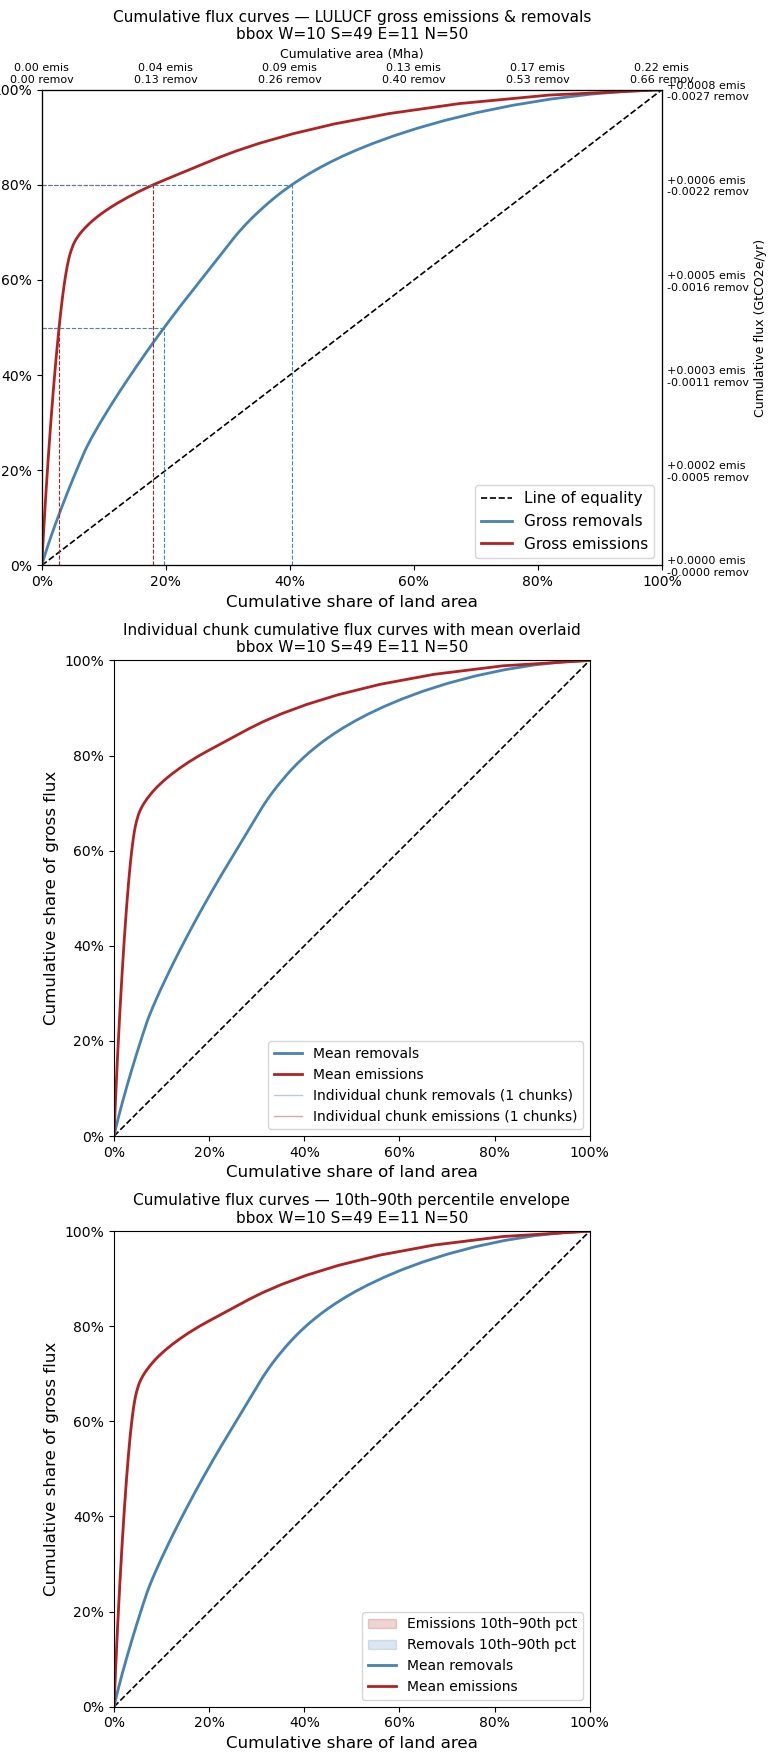

2026-06-15 14:10:11,999 - distributed.client - ERROR - Failed to reconnect to scheduler after 30.00 seconds, closing client


In [44]:
%%time

### Global cumulative flux curves from 1x1 deg per-ha gross emissions and gross removals chunks — Coiled parallel version
### Histogram approach: memory-efficient, scalable to global
### Creates two panels: (1) combined global curves, (2) individual chunk curves + mean overlaid
### Per Claude session `Lorenz curves for LULUCF emissions/removals` and 'Lorenz curves for LULUCF emissions/removals, pt2'

# ── Coiled configuration ───────────────────────────────────────────────────
CLUSTER_NAME  = 'LULUCF_flux_accum_curve'
N_WORKERS     = 100
WORKER_MEMORY = 8       # GiB — sufficient for per-chunk raster reads
RUN_LOCAL     = False   # True: run serially without Coiled (for testing)
BATCH_SIZE    = 3000     # chunks per gather batch; bounds memory on scheduler

# ── Analysis configuration ─────────────────────────────────────────────────

PERIOD = "avg_2016_2024"

SINGLE_CHUNK  = None
BOUNDING_BOX  = [10, 49, 11, 50]
# BOUNDING_BOX  = [10, 40, 20, 50]
# BOUNDING_BOX  = [40, 50, 70, 60]
# BOUNDING_BOX  = [10, 47, 13, 50]
# BOUNDING_BOX  = [0, -10, 15, 0]
# BOUNDING_BOX = None
# SHAPEFILE_URI = "s3://gfw2-data/climate/AFOLU_flux_model/fishnet_1x1deg/20250429/fishnet_GADM41_1x1deg__spatial_join_intersect__20250428__center_in.shp"
SHAPEFILE_URI = None
FIRST_CHUNKS  = None

N_BINS           = 10_000
INTENSITY_MIN    = 1e-6     # MgCO2e/ha/yr
INTENSITY_MAX    = 1e5      # MgCO2e/ha/yr
MIN_VALID_PIXELS = 1000
N_PLOT_POINTS    = 200
INDIVIDUAL_ALPHA = 0.05

BASE     = ("s3://gfw2-data/climate/AFOLU_flux_model/LULUCF/outputs_LULUCF_totals/LULUCF_version_1_0_0_standard__global__veg_v1_0_5__org_soil_v1_0_1__min_soil_v1_0_1")
EMIS_DIR = (f"{BASE}/LULUCF_gross_emissions__all_C_pools__all_gases__MgCO2e/annual_intervals/avg_2016_2024/_ha_yr/4000_pixels/20260614")
REMV_DIR = (f"{BASE}/LULUCF_gross_removals__all_C_pools__MgCO2/annual_intervals/avg_2016_2024/_ha_yr/4000_pixels/20260614")

# ── Build chunk list ───────────────────────────────────────────────────────
if SINGLE_CHUNK is not None:
    chunk_list = [SINGLE_CHUNK]
    area_label = f"chunk {SINGLE_CHUNK}"
elif BOUNDING_BOX is not None:
    chunk_list = uu.get_chunk_bounds_from_bounding_box(BOUNDING_BOX, chunk_size=1.0)
    area_label = f"bbox W={BOUNDING_BOX[0]} S={BOUNDING_BOX[1]} E={BOUNDING_BOX[2]} N={BOUNDING_BOX[3]}"
elif SHAPEFILE_URI is not None:
    fishnet_iso_df = uu.fishnet_with_GADM_iso(SHAPEFILE_URI)
    if FIRST_CHUNKS:
        fishnet_iso_df = fishnet_iso_df[:FIRST_CHUNKS]
    chunk_list = fishnet_iso_df['chunk_id'].apply(uu.process_chunk_id).tolist()
    area_label = SHAPEFILE_URI.split('/')[-1]
else:
    raise ValueError("Set one of SINGLE_CHUNK, BOUNDING_BOX, or SHAPEFILE_URI")

print(f"Chunks to process: {len(chunk_list):,}")

# ── Worker function ────────────────────────────────────────────────────────
def process_chunk_lorenz(bounds, period, emis_dir, remv_dir,
                          n_bins, intensity_min, intensity_max,
                          min_valid_pixels, n_plot_points):
    """
    Processes one 1x1 deg chunk on a Coiled worker.
    Returns partial histogram accumulators and a downsampled cumulative flux curve.
    All imports are local so the function is self-contained on the worker.
    bin_edges reconstructed from scalars to avoid serialising a large array
    for every task submission.
    Lorenz sort is descending (highest intensity first) → curves go up-then-right.
    """
    import numpy as np
    import rasterio
    from src.utilities import universal_utilities as uu

    w, s, e, n = bounds
    tile_id    = uu.xy_to_tile_id(w, n)
    bounds_str = uu.boundstr(bounds)
    emis_path  = (f"{emis_dir}/{tile_id}__{bounds_str}__"
                  f"LULUCF_gross_emissions__all_C_pools__all_gases__MgCO2e_ha_yr_{period}.tif")
    remv_path  = (f"{remv_dir}/{tile_id}__{bounds_str}__"
                  f"LULUCF_gross_removals__all_C_pools__MgCO2_ha_yr_{period}.tif")

    bin_edges = np.logspace(np.log10(intensity_min), np.log10(intensity_max), n_bins + 1)
    x_uniform = np.linspace(0, 1, n_plot_points)

    def pixel_area_ha_by_row(src):
        t           = src.transform
        row_idx     = np.arange(src.height)
        lat_centers = t.f + (row_idx + 0.5) * t.e
        d_lat_rad   = abs(t.e) * np.pi / 180
        d_lon_rad   = abs(t.a) * np.pi / 180
        area_km2    = 6371.0**2 * d_lat_rad * d_lon_rad * np.cos(np.deg2rad(lat_centers))
        return area_km2 * 100

    def lorenz_from_histogram(bin_area, bin_flux):
        """Descending sort → curves go up-then-right, above diagonal."""
        occupied = (bin_area > 0) | (bin_flux > 0)
        if not occupied.any():
            return None, None
        cum_area = np.concatenate([[0.0], np.cumsum(bin_area[occupied][::-1])])
        cum_flux = np.concatenate([[0.0], np.cumsum(bin_flux[occupied][::-1])])
        if cum_area[-1] == 0 or cum_flux[-1] == 0:
            return None, None
        return cum_area / cum_area[-1], cum_flux / cum_flux[-1]

    result = {
        'emis_bin_area': np.zeros(n_bins),
        'emis_bin_flux': np.zeros(n_bins),
        'remv_bin_area': np.zeros(n_bins),
        'remv_bin_flux': np.zeros(n_bins),
        'n_emis_valid' : 0,
        'n_remv_valid' : 0,
        'chunk_emis_y' : None,
        'chunk_remv_y' : None,
        'status'       : 'ok',
    }

    try:
        with rasterio.open(emis_path) as src:
            emis_grid = src.read(1).astype(np.float64)
            areas_1d  = pixel_area_ha_by_row(src)
            area_grid = np.broadcast_to(areas_1d[:, np.newaxis], emis_grid.shape)
        with rasterio.open(remv_path) as src:
            remv_grid = src.read(1).astype(np.float64)
    except Exception as ex:
        result['status'] = f'missing: {ex}'
        return result

    # Emissions
    emis_mask = emis_grid > 0
    n_emis    = int(emis_mask.sum())
    result['n_emis_valid'] = n_emis
    if n_emis > 0:
        e_ha      = emis_grid[emis_mask]
        e_ha_area = area_grid[emis_mask]
        e_flux    = e_ha * e_ha_area
        bidx      = np.clip(
            np.searchsorted(bin_edges, e_ha, side='right') - 1, 0, n_bins - 1
        )
        result['emis_bin_area'] += np.bincount(bidx, weights=e_ha_area, minlength=n_bins)
        result['emis_bin_flux'] += np.bincount(bidx, weights=e_flux,    minlength=n_bins)
        if n_emis >= min_valid_pixels:
            cx, cy = lorenz_from_histogram(result['emis_bin_area'], result['emis_bin_flux'])
            if cx is not None:
                result['chunk_emis_y'] = np.interp(x_uniform, cx, cy)

    # Removals
    remv_mask = remv_grid < 0
    n_remv    = int(remv_mask.sum())
    result['n_remv_valid'] = n_remv
    if n_remv > 0:
        r_ha      = np.abs(remv_grid[remv_mask])
        r_ha_area = area_grid[remv_mask]
        r_flux    = r_ha * r_ha_area
        bidx      = np.clip(
            np.searchsorted(bin_edges, r_ha, side='right') - 1, 0, n_bins - 1
        )
        result['remv_bin_area'] += np.bincount(bidx, weights=r_ha_area, minlength=n_bins)
        result['remv_bin_flux'] += np.bincount(bidx, weights=r_flux,    minlength=n_bins)
        if n_remv >= min_valid_pixels:
            cx, cy = lorenz_from_histogram(result['remv_bin_area'], result['remv_bin_flux'])
            if cx is not None:
                result['chunk_remv_y'] = np.interp(x_uniform, cx, cy)

    return result

# ── Connect to cluster (or fall back to local) ─────────────────────────────
cluster, client, run_local = uu.connect_to_Coiled_cluster(
    CLUSTER_NAME, RUN_LOCAL, fallback_to_local_on_failure=False
)

# # If no running cluster found, create one
# if cluster is None and not RUN_LOCAL:
#     print(f"No running cluster '{CLUSTER_NAME}' found — creating one...")
#     cluster = cc_create_cluster(CLUSTER_NAME, N_WORKERS, WORKER_MEMORY, threads_per_worker=1)
#     client  = Client(cluster)
#     print(f"Cluster ready: {cluster.dashboard_link}")

# ── Global accumulators ────────────────────────────────────────────────────
emis_bin_area     = np.zeros(N_BINS, dtype=np.float64)
emis_bin_flux     = np.zeros(N_BINS, dtype=np.float64)
remv_bin_area     = np.zeros(N_BINS, dtype=np.float64)
remv_bin_flux     = np.zeros(N_BINS, dtype=np.float64)
chunk_emis_curves = []
chunk_remv_curves = []
x_uniform         = np.linspace(0, 1, N_PLOT_POINTS)
n_ok              = 0
n_missing         = 0
n_skipped_emis    = 0
n_skipped_remv    = 0

# ── Shared task kwargs ─────────────────────────────────────────────────────
task_kwargs = dict(
    period           = PERIOD,
    emis_dir         = EMIS_DIR,
    remv_dir         = REMV_DIR,
    n_bins           = N_BINS,
    intensity_min    = INTENSITY_MIN,
    intensity_max    = INTENSITY_MAX,
    min_valid_pixels = MIN_VALID_PIXELS,
    n_plot_points    = N_PLOT_POINTS,
)

def _aggregate(result):
    """Aggregate one worker result into global accumulators."""
    global n_ok, n_missing, n_skipped_emis, n_skipped_remv
    global emis_bin_area, emis_bin_flux, remv_bin_area, remv_bin_flux
    global chunk_emis_curves, chunk_remv_curves
    if result['status'] != 'ok':
        n_missing += 1
        return
    emis_bin_area += result['emis_bin_area']
    emis_bin_flux += result['emis_bin_flux']
    remv_bin_area += result['remv_bin_area']
    remv_bin_flux += result['remv_bin_flux']
    if result['chunk_emis_y'] is not None:
        chunk_emis_curves.append(result['chunk_emis_y'])
    else:
        n_skipped_emis += 1
    if result['chunk_remv_y'] is not None:
        chunk_remv_curves.append(result['chunk_remv_y'])
    else:
        n_skipped_remv += 1
    n_ok += 1

# ── Process: Coiled (parallel) or local (serial) ───────────────────────────
chunk_batches = [chunk_list[i:i + BATCH_SIZE]
                 for i in range(0, len(chunk_list), BATCH_SIZE)]

if client is not None:
    print(f"Submitting {len(chunk_list):,} chunks in "
          f"{len(chunk_batches)} batches of {BATCH_SIZE}...")

    for i, batch in enumerate(chunk_batches):
        futures = [
            client.submit(
                process_chunk_lorenz,
                bounds,
                **task_kwargs,
                key=f"lorenz-{int(bounds[0])}_{int(bounds[1])}_{int(bounds[2])}_{int(bounds[3])}"
            )
            for bounds in batch
        ]
        for future in tqdm(
            as_completed(futures),
            total=len(futures),
            desc=f"Batch {i+1}/{len(chunk_batches)}"
        ):
            try:
                _aggregate(future.result())
            except Exception as ex:
                n_missing += 1
                print(f"  Future failed: {ex}")

else:
    print("Running locally (no Coiled cluster)...")
    for bounds in tqdm(chunk_list, desc=f"Processing chunks"):
        result = process_chunk_lorenz(bounds, **task_kwargs)
        _aggregate(result)

print(f"\nDone — processed: {n_ok:,}  |  missing/skipped: {n_missing:,}")
print(f"Chunks below {MIN_VALID_PIXELS} pixel threshold — "
      f"emissions: {n_skipped_emis:,}  removals: {n_skipped_remv:,}")

# ── Reconstruct cumulative flux curves from histogram (descending intensity) ──
def lorenz_from_histogram(bin_area, bin_flux):
    """Descending sort (highest intensity first) → curves go up-then-right,
    above the diagonal. Returns (cum_area_frac, cum_flux_frac), both 0→1."""
    occupied = (bin_area > 0) | (bin_flux > 0)
    cum_area = np.concatenate([[0.0], np.cumsum(bin_area[occupied][::-1])])
    cum_flux = np.concatenate([[0.0], np.cumsum(bin_flux[occupied][::-1])])
    return cum_area / cum_area[-1], cum_flux / cum_flux[-1]

def gini(x, y):
    """For a curve above the diagonal (descending sort): Gini = 2*trapz(y,x) - 1."""
    return 2.0 * np.trapezoid(y, x) - 1.0

emis_x, emis_y = lorenz_from_histogram(emis_bin_area, emis_bin_flux)
remv_x,  remv_y = lorenz_from_histogram(remv_bin_area,  remv_bin_flux)

emis_area_Mha = emis_bin_area.sum() / 1e6
remv_area_Mha = remv_bin_area.sum() / 1e6
emis_flux_Gt  = emis_bin_flux.sum() / 1e9
remv_flux_Gt  = remv_bin_flux.sum() / 1e9

# ── Plot ───────────────────────────────────────────────────────────────────
pct_ticks = np.array([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 21))

# ── Panel 1: combined global curves ───────────────────────────────────────
ax1.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Line of equality')
ax1.plot(remv_x, remv_y, color='steelblue', lw=2,
         label=f'Gross removals') #   (Gini = {gini(remv_x, remv_y):.3f})')
ax1.plot(emis_x, emis_y, color='firebrick', lw=2,
         label=f'Gross emissions') #  (Gini = {gini(emis_x, emis_y):.3f})')

# 80% emissions reference lines
x_80  = np.interp(0.80, emis_y, emis_x)
ax1.axvline(x=x_80,  ymin=0, ymax=0.80, color='firebrick',  lw=0.8, ls='--')
ax1.axhline(y=0.80,  xmin=0, xmax=x_80, color='firebrick',  lw=0.8, ls='--')

# 80% removals reference lines
x_80r = np.interp(0.80, remv_y, remv_x)
ax1.axvline(x=x_80r, ymin=0, ymax=0.80, color='steelblue', lw=0.8, ls='--')
ax1.axhline(y=0.80,  xmin=0, xmax=x_80r, color='steelblue', lw=0.8, ls='--')

# 50% emissions reference lines
x_50  = np.interp(0.50, emis_y, emis_x)
ax1.axvline(x=x_50,  ymin=0, ymax=0.50, color='firebrick',  lw=0.8, ls='--')
ax1.axhline(y=0.50,  xmin=0, xmax=x_50, color='firebrick',  lw=0.8, ls='--')

# 50% removals reference lines
x_50r = np.interp(0.50, remv_y, remv_x)
ax1.axvline(x=x_50r, ymin=0, ymax=0.50, color='steelblue', lw=0.8, ls='--')
ax1.axhline(y=0.50,  xmin=0, xmax=x_50r, color='steelblue', lw=0.8, ls='--')

ax1.set_xlabel('Cumulative share of land area', fontsize=12)
ax1.set_title(
    f'Cumulative flux curves — LULUCF gross emissions & removals\n{area_label}',
    fontsize=11
)
ax1.legend(fontsize=11, loc='lower right')
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.set_box_aspect(1)

ax1_right = ax1.twinx()
ax1_top   = ax1.twiny()
ax1.set_xticks(pct_ticks)
ax1.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax1.set_yticks(pct_ticks)
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax1_right.set_ylim(0, 1)
ax1_right.set_yticks(pct_ticks)
ax1_right.set_yticklabels(
    [f"+{v * emis_flux_Gt:.4f} emis\n{-v * remv_flux_Gt:.4f} remov" for v in pct_ticks],
    fontsize=8
)
ax1_right.set_ylabel('Cumulative flux (GtCO2e/yr)', fontsize=9)
ax1_right.tick_params(axis='y', length=0)
ax1_top.set_xlim(0, 1)
ax1_top.set_xticks(pct_ticks)
ax1_top.set_xticklabels(
    [f"{v * emis_area_Mha:.2f} emis\n{v * remv_area_Mha:.2f} remov" for v in pct_ticks],
    fontsize=8
)
ax1_top.set_xlabel('Cumulative area (Mha)', fontsize=9)
ax1_top.tick_params(axis='x', length=0)

# ── Panel 2: individual chunk curves + mean overlaid ──────────────────────
if chunk_emis_curves:
    segs = [np.column_stack([x_uniform, y]) for y in chunk_emis_curves]
    ax2.add_collection(LineCollection(
        segs, color='firebrick', alpha=INDIVIDUAL_ALPHA, linewidth=0.5
    ))
if chunk_remv_curves:
    segs = [np.column_stack([x_uniform, y]) for y in chunk_remv_curves]
    ax2.add_collection(LineCollection(
        segs, color='steelblue', alpha=INDIVIDUAL_ALPHA, linewidth=0.5
    ))
ax2.plot([0, 1], [0, 1], 'k--', lw=1.2)
ax2.plot(remv_x, remv_y, color='steelblue', lw=2,
         label=f'Mean removals') #   (Gini = {gini(remv_x, remv_y):.3f})')
ax2.plot(emis_x, emis_y, color='firebrick', lw=2,
         label=f'Mean emissions') #  (Gini = {gini(emis_x, emis_y):.3f})')
ax2.legend(
    handles=[
        ax2.get_lines()[1],
        ax2.get_lines()[2],
        Line2D([0], [0], color='steelblue', alpha=0.4, lw=1,
               label=f'Individual chunk removals ({len(chunk_remv_curves):,} chunks)'),
        Line2D([0], [0], color='firebrick',  alpha=0.4, lw=1,
               label=f'Individual chunk emissions ({len(chunk_emis_curves):,} chunks)'),
    ],
    fontsize=10, loc='lower right'
)
ax2.set_xlabel('Cumulative share of land area', fontsize=12)
ax2.set_ylabel('Cumulative share of gross flux', fontsize=12)
ax2.set_title(
    f'Individual chunk cumulative flux curves with mean overlaid\n{area_label}',
    fontsize=11
)
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.set_xticks(pct_ticks)
ax2.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax2.set_yticks(pct_ticks)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax2.set_box_aspect(1)


# ── Panel 3: percentile envelope around mean curves ────────────────────────
if chunk_emis_curves:
    emis_arr = np.array(chunk_emis_curves)   # (n_chunks, N_PLOT_POINTS)
    emis_p10 = np.percentile(emis_arr, 10, axis=0)
    emis_p90 = np.percentile(emis_arr, 90, axis=0)
    ax3.fill_between(x_uniform, emis_p10, emis_p90,
                     color='firebrick', alpha=0.2, label='Emissions 10th–90th pct')

if chunk_remv_curves:
    remv_arr = np.array(chunk_remv_curves)
    remv_p10 = np.percentile(remv_arr, 10, axis=0)
    remv_p90 = np.percentile(remv_arr, 90, axis=0)
    ax3.fill_between(x_uniform, remv_p10, remv_p90,
                     color='steelblue', alpha=0.2, label='Removals 10th–90th pct')

ax3.plot([0, 1], [0, 1], 'k--', lw=1.2)
ax3.plot(remv_x, remv_y, color='steelblue', lw=2, label='Mean removals')
ax3.plot(emis_x, emis_y, color='firebrick',  lw=2, label='Mean emissions')
ax3.legend(fontsize=10, loc='lower right')
ax3.set_xlabel('Cumulative share of land area', fontsize=12)
ax3.set_ylabel('Cumulative share of gross flux', fontsize=12)
ax3.set_title(
    f'Cumulative flux curves — 10th–90th percentile envelope\n{area_label}',
    fontsize=11
)
ax3.set_xlim(0, 1)
ax3.set_ylim(0, 1)
ax3.set_xticks(pct_ticks)
ax3.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax3.set_yticks(pct_ticks)
ax3.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax3.set_box_aspect(1)


# ── Validation summary ─────────────────────────────────────────────────────
print("=" * 57)
print("VALIDATION SUMMARY")
print("=" * 57)
print(f"Chunks processed : {n_ok:,}  |  missing: {n_missing:,}")
print(f"Histogram bins   : {N_BINS:,}  (log {INTENSITY_MIN:.0e}–{INTENSITY_MAX:.0e} MgCO2e/ha/yr)")
print(f"Min valid pixels : {MIN_VALID_PIXELS:,}")
print(f"Chunks in individual curves — emissions: {len(chunk_emis_curves):,}  "
      f"removals: {len(chunk_remv_curves):,}")

print(f"\nLand area covered:")
print(f"  Emitting land         : {emis_area_Mha:>10.2f} Mha")
print(f"  Removing land         : {remv_area_Mha:>10.2f} Mha")

print(f"\nConcentration — emissions (total: {emis_area_Mha:.2f} Mha, +{emis_flux_Gt:.5f} GtCO2e/yr):")
for pct in [10, 25, 50]:
    idx       = np.searchsorted(emis_x, pct / 100)
    flux_frac = emis_y[idx]
    print(f"  Top {pct:2d}% most intensive ({pct/100 * emis_area_Mha:.2f} Mha) → "
          f"{100*flux_frac:.1f}% of gross emissions (+{flux_frac * emis_flux_Gt:.5f} GtCO2e/yr)")

print(f"\nConcentration — removals (total: {remv_area_Mha:.2f} Mha, -{remv_flux_Gt:.5f} GtCO2e/yr):")
for pct in [10, 25, 50]:
    idx       = np.searchsorted(remv_x, pct / 100)
    flux_frac = remv_y[idx]
    print(f"  Top {pct:2d}% most intensive ({pct/100 * remv_area_Mha:.2f} Mha) → "
          f"{100*flux_frac:.1f}% of gross removals (-{flux_frac * remv_flux_Gt:.5f} GtCO2e/yr)")

print(f"\nGini coefficients:")
print(f"  Gross emissions       : {gini(emis_x, emis_y):.4f}")
print(f"  Gross removals        : {gini(remv_x, remv_y):.4f}")

print(f"\nCurve endpoint check (should both be exactly 1.0):")
print(f"  Emissions             : x={emis_x[-1]:.6f},  y={emis_y[-1]:.6f}")
print(f"  Removals              : x={remv_x[-1]:.6f},  y={remv_y[-1]:.6f}")

print(f"\nCurve data table (area fraction needed to reach each flux level):")
flux_pcts = [10, 25, 50, 75, 80, 90, 95, 100]
hdr = f"  {'Flux %':>6}  {'Emis area %':>11}  {'Emis area (Mha)':>15}  {'Emis flux (GtCO2e)':>18}  {'Remv area %':>11}  {'Remv area (Mha)':>15}  {'Remv flux (GtCO2e)':>18}"
print(hdr)
print("  " + "─" * (len(hdr) - 2))
for fp in flux_pcts:
    frac      = fp / 100
    ex        = np.interp(frac, emis_y, emis_x)
    rx        = np.interp(frac, remv_y, remv_x)
    print(f"  {fp:>5}%  {100*ex:>10.1f}%  {ex*emis_area_Mha:>15.2f}  {frac*emis_flux_Gt:>18.5f}  "
          f"{100*rx:>10.1f}%  {rx*remv_area_Mha:>15.2f}  {frac*remv_flux_Gt:>18.5f}")

# ── Detailed curve table (sufficient to recreate curves) ───────────────────
x_fine = np.linspace(0, 1, 1001)   # 0.1% steps

emis_y_fine = np.interp(x_fine, emis_x, emis_y)
remv_y_fine = np.interp(x_fine, remv_x, remv_y)

curve_df = pd.DataFrame({
    'cum_area_frac'       : x_fine,
    'emis_cum_flux_frac'  : emis_y_fine,
    'remv_cum_flux_frac'  : remv_y_fine,
    'cum_area_Mha_emis'   : x_fine * emis_area_Mha,
    'cum_area_Mha_remov'  : x_fine * remv_area_Mha,
    'emis_cum_flux_GtCO2e': emis_y_fine * emis_flux_Gt,
    'remv_cum_flux_GtCO2e': remv_y_fine * remv_flux_Gt,
})

# Metadata rows appended as footer comments when saving
meta = {
    'area_label'      : area_label,
    'period'          : PERIOD,
    'emis_total_Mha'  : emis_area_Mha,
    'remv_total_Mha'  : remv_area_Mha,
    'emis_total_GtCO2e': emis_flux_Gt,
    'remv_total_GtCO2e': remv_flux_Gt,
    'gini_emis'       : gini(emis_x, emis_y),
    'gini_remv'       : gini(remv_x, remv_y),
    'n_chunks_ok'     : n_ok,
    'n_chunks_missing': n_missing,
}

print(f"\nDetailed curve table ({len(curve_df):,} rows × {len(curve_df.columns)} columns):")
# print(curve_df.to_string(index=False, float_format=lambda v: f"{v:.6f}"))

# Save to CSV alongside the notebook
LULUCF_zonal_stats_folder = Path(f'/mnt/c/GIS/AFOLU_flux_model/LULUCF/zonal_statistics/LULUCF_v{cn.LULUCF_model_version_underscore}__veg_v{cn.veg_model_version_underscore}__minsoil_v{cn.SOC_model_version_underscore}__orgsoil_v{cn.organic_soil_model_version_underscore}/')
csv_path = f"{LULUCF_zonal_stats_folder}/flux_accum_curves__{area_label.replace(' ', '_').replace('=', '').replace(',', '')}_{PERIOD}.csv"
curve_df.to_csv(csv_path, index=False, float_format='%.8f')
meta_path = csv_path.replace('.csv', '__meta.csv')
pd.Series(meta).to_csv(meta_path, header=False)
print(f"\nSaved: {csv_path}")
print(f"Saved: {meta_path}")

# # ── Shut down cluster when done ────────────────────────────────────────────
# if cluster is not None:
#     print("\nShutting down cluster...")
#     client.close()
#     cluster.shutdown()